# Predictive Analysis of Maternal Anemia Risk in India using NFHS-5 Data

**Project:** IV Semester Statistical Data Analysis Project  

**Dataset:** National Family Health Survey-5 (NFHS-5), India  

---

## Notebook Outline

1. **Data Description** — metadata, variable dictionary, missing-value audit
2. **Exploratory Data Analysis (EDA)** — univariate, bivariate, correlation
3. **Statistical Hypothesis Testing** — Chi-square & Independent T-test
4. **Advanced Modeling** — Logistic Regression, Random Forest, XGBoost, PCA / RFE, SMOTE
5. **Results & Appendix** — classification reports and confusion matrices

> **Target variable:** `v457` — Anaemia level of the woman (1 = Severe, 2 = Moderate, 3 = Mild, 4 = Not anaemic).  
> For binary modelling we collapse this into **Anaemic (1–3)** vs **Not Anaemic (4)**.


# Notebook Outline

This notebook presents a complete statistical and machine learning analysis of maternal anemia using the National Family Health Survey-5 (NFHS-5), India dataset.

## 1. Setup
- Import required Python libraries

## 2. Data Loading & Description
- Load the NFHS-5 dataset
- Variable dictionary (codes to readable names)
- Dataset metadata
- Statistical summary
- Missing value audit

## 3. Data Cleaning & Feature Engineering
- Handle missing values
- Create cleaned variables (BMI, Hemoglobin, Weight)
- Remove highly missing variables
- Create binary target variable (Anemia Status)

## 4. Exploratory Data Analysis (EDA)
- Univariate Analysis
- Categorical Count Plots
- Bivariate Analysis
- Boxplots
- Correlation Heatmap

## 5. Statistical Hypothesis Testing
- Chi-Square Test of Association
- Independent Samples t-Test
- Statistical Summary

## 6. Predictive Analysis
- Feature Selection
- Train-Test Split
- Feature Scaling
- SMOTE (Class Balancing)
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Model Comparison
- Accuracy Comparison
- Confusion Matrices
- Feature Importance

## 7. Conclusion

## 8. Future Scope

---

### Dataset
**National Family Health Survey-5 (NFHS-5), India**

### Target Variable
**v457 – Anaemia Level**

- 1 = Severe
- 2 = Moderate
- 3 = Mild
- 4 = Not Anaemic

For predictive modelling, the target variable is converted into a binary outcome:

- **1 = Anaemic (Severe + Moderate + Mild)**
- **0 = Not Anaemic**

## 1. Setup — Library Imports

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

# Pre-processing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Class-imbalance handling
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)

warnings.filterwarnings('ignore')

## 2. Data Loading & Description

### 2.1 Load the NFHS-5 dataset

In [3]:
# Load the NFHS-5 dataset
# NOTE: update DATA_PATH to wherever NFHS5_data.csv lives on your machine.
# Using a relative path + a clear error message instead of a hardcoded
# absolute Windows path makes this notebook portable across machines/OSes.
import os

DATA_PATH = os.environ.get('NFHS5_DATA_PATH', r'C:\Projects\19-21\NFHS5_data.csv')

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Either place NFHS5_data.csv in the "
        f"notebook's working directory, or set the NFHS5_DATA_PATH "
        f"environment variable to its full path before launching Jupyter."
    )

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head()


Dataset shape: 724,115 rows  ×  40 columns


,v001,v002,v012,v013,v024,v025,v106,v113,v116,v119,...,m45_1,v437,v445,v456,v457,v501,v731,v741,sb20,sb56
0,113,5,22,2,1,2,3,14,12.0,1,...,NaN,353.0,1734.0,106,2.0,0,NaN,NaN,0.0,0.0
1,113,5,19,1,1,2,2,14,12.0,1,...,NaN,310.0,1586.0,82,2.0,0,NaN,NaN,0.0,0.0
2,113,45,38,5,1,2,1,14,44.0,1,...,NaN,755.0,3449.0,83,2.0,1,NaN,NaN,0.0,0.0
3,113,83,40,6,1,2,0,14,12.0,1,...,NaN,708.0,2673.0,72,1.0,1,NaN,NaN,0.0,0.0
4,113,83,22,2,1,2,3,14,12.0,1,...,NaN,358.0,1533.0,93,2.0,0,NaN,NaN,0.0,0.0


In [4]:
df.columns

Index(['v001', 'v002', 'v012', 'v013', 'v024', 'v025', 'v106', 'v113', 'v116',
       'v119', 'v121', 'v130', 'v133', 'v136', 'v137', 'v155', 'v161', 'v190',
       'v191', 'v201', 'v208', 'v212', 'v213', 'v218', 'v228', 'v312', 'v313',
       'm14_1', 'm15_1', 'm17_1', 'm45_1', 'v437', 'v445', 'v456', 'v457',
       'v501', 'v731', 'v741', 'sb20', 'sb56'],
      dtype='str')

### 2.2 NFHS-5 Variable Dictionary (Codes → Readable Names)

NFHS variable names are short codes (e.g., `v457`, `v025`). The dictionary below maps every code in our file to its readable description so the same names can be used in the report's *Detailed Data Variable Description* section.

# NFHS/DHS Variable Dictionary

| Variable | Description | Values / Categories |
|----------|-------------|---------------------|
| **V001** | Cluster number | Numeric |
| **V002** | Household number | Numeric |
| **V012** | Respondent's current age | Numeric (15–49 years) |
| **V013** | Age in 5-year groups | 1 = 15–19, 2 = 20–24, 3 = 25–29, 4 = 30–34, 5 = 35–39, 6 = 40–44, 7 = 45–49, NA = Not applicable |
| **V024** | Region | 1 = Region 1, 2 = Region 2, 3 = Region 3, 4 = Region 4 |
| **V025** | Type of place of residence | 1 = Urban, 2 = Rural |
| **V106** | Highest educational level | 0 = No education, 1 = Primary, 2 = Secondary, 3 = Higher, 9 = Missing |
| **V113** | Source of drinking water | 11 = Piped into dwelling, 12 = Piped to yard/plot, 13 = Piped to neighbor, 14 = Public tap/standpipe, 21 = Tube well/Borehole, 31 = Protected well, 32 = Unprotected well, 41 = Protected spring, 42 = Unprotected spring, 43 = River/Lake/Stream, 51 = Rainwater, 61 = Tanker truck, 62 = Cart with small tank, 71 = Bottled water, 96 = Other, 97 = Not a de jure resident, 99 = Missing |
| **V116** | Type of toilet facility | 11 = Flush to sewer, 12 = Flush to septic tank, 13 = Flush to pit latrine, 14 = Flush elsewhere, 15 = Don't know, 21 = VIP latrine, 22 = Pit latrine with slab, 23 = Pit latrine without slab, 31 = No facility, 41 = Composting toilet, 42 = Bucket toilet, 43 = Hanging toilet, 96 = Other, 97 = Not a de jure resident, 99 = Missing |
| **V119** | Household has electricity | 0 = No, 1 = Yes, 7 = Not a de jure resident, 9 = Missing |
| **V121** | Household has television | 0 = No, 1 = Yes, 7 = Not a de jure resident, 9 = Missing |
| **V130** | Religion | 96 = Other, 99 = Missing |
| **V133** | Education in single years | 0–20 years, 97 = Inconsistent, 99 = Missing |
| **V136** | Number of household members | Numeric |
| **V137** | Number of children aged 5 and under | Numeric |
| **V155** | Literacy | 0 = Cannot read, 1 = Reads part of sentence, 2 = Reads whole sentence, 3 = No card available, 4 = Blind/Visually impaired, 9 = Missing |
| **V161** | Type of cooking fuel | 1 = Electricity, 2 = LPG, 3 = Natural gas, 4 = Biogas, 5 = Kerosene, 6 = Coal/Lignite, 7 = Charcoal, 8 = Wood, 9 = Straw/Shrubs/Grass, 10 = Agricultural crop, 11 = Animal dung, 95 = No food cooked, 96 = Other, 97 = Not a de jure resident, 99 = Missing |
| **V190** | Wealth index | 1 = Poorest, 2 = Poorer, 3 = Middle, 4 = Richer, 5 = Richest |
| **V191** | Wealth index factor score | Continuous |
| **V201** | Total children ever born | 0–20 |
| **V208** | Births in last five years | 0 = No births, 1–6 = Number of births |
| **V212** | Age at first birth | 10–49 years |
| **V213** | Currently pregnant | 0 = No/Unsure, 1 = Yes |
| **V218** | Number of living children | 0–20 |
| **V228** | Ever had a terminated pregnancy | 0 = No, 1 = Yes, 9 = Missing |
| **V312** | Current contraceptive method | 0 = Not using, 1 = Pill, 2 = IUD, 3 = Injections, 4 = Diaphragm, 5 = Male condom, 6 = Female sterilization, 7 = Male sterilization, 8 = Periodic abstinence, 9 = Withdrawal, 10 = Other traditional, 11 = Implants, 12 = Prolonged abstinence, 13 = Lactational amenorrhea, 14 = Female condom, 15 = Foam/Jelly, 16 = Emergency contraception, 17 = Other modern method, 18 = Standard Days Method, 19–20 = Specific methods, 99 = Missing |
| **V313** | Current contraceptive method type | 0 = No method, 1 = Folkloric, 2 = Traditional, 3 = Modern, 9 = Missing |
| **M14_1** | Number of antenatal visits | 0 = None, 1–40 = Number of visits, 98 = Don't know, 99 = Missing |
| **M15_1** | Place of delivery | 11 = Respondent's home, 12 = Other home, 21 = Government hospital, 22–29 = Government health facility, 31 = Private hospital/clinic, 32–36 = Private health facility, 96 = Other, 99 = Missing |
| **M17_1** | Delivery by caesarean section | 0 = No, 1 = Yes, 9 = Missing |
| **M45_1** | Received iron tablets during pregnancy | 0 = No, 1 = Yes, 8 = Don't know, 9 = Missing |
| **V437** | Respondent's weight (kg) | 200–2000 (stored with one decimal), 9994 = Not present, 9995 = Refused, 9996 = Other, 9999 = Missing |
| **V456** | Hemoglobin level (adjusted) | Continuous, 999 = Missing |
| **V457** | Anemia level | 1 = Severe, 2 = Moderate, 3 = Mild, 4 = Not anemic, 9 = Missing |

In [5]:
# Mapping of NFHS-5 codes to descriptive names
nfhs_dict = {
    'v001':  'Cluster number',
    'v002':  'Household number',
    'v012':  "Respondent's current age (years)",
    'v013':  'Age in 5-year groups',
    'v024':  'Region',
    'v025':  'Type of place of residence (1=Urban, 2=Rural)',
    'v106':  'Highest educational level',
    'v113':  'Source of drinking water',
    'v116':  'Type of toilet facility',
    'v119':  'Household has: electricity',
    'v121':  'Household has: telivision',
    'v130':  'Religion',
    'v133':  'Education in single years',
    'v136':  'Number of household members',
    'v137':  'Number of children 5 and under in household',
    'v155':  'Literacy',
    'v161':  'Type of cooking fuel',
    'v190':  'Wealth index combined',
    'v191':  'Wealth index factor score combined',
    'v201':  'Total children ever born',
    'v208':  'Births in last five years',
    'v212':  'Age of respondent at first birth',
    'v213':  'Currently pregnant',
    'v218':  'Number of living children',
    'v228':  'Ever had a terminated pregnancy',
    'v312':  'Current contraceptive method',
    'v313':  'Current use by method type',
    'm14_1': 'Number of antenatal visits (last birth)',
    'm15_1': 'Place of delivery (last birth)',  
    'm17_1': 'Delivery by caesarean section (last birth)',
    'm45_1': 'Took iron supplements during pregnancy',
    'v437':  'Weight (Kilograms ×10)',
    'v445':  'Body Mass Index (BMI ×100)',
    'v456':  'Hemoglobin Level (g/dL ×10)',
    'v457':  'Anemia Level (Target Variable: 1=Severe, 2=Moderate, 3=Mild, 4=Not Anemic)',
    'v501':  'Current marital status',
    'v731':  'Respondent worked in last 12 months',
    'v741':  'Type of earnings for work'
}

variable_dictionary = pd.DataFrame(
    [(c, nfhs_dict.get(c, 'Unknown')) for c in df.columns],
    columns=['NFHS Code', 'Readable Description']
)
variable_dictionary

,NFHS Code,Readable Description
0,v001,Cluster number
1,v002,Household number
2,v012,Respondent's current age (years)
3,v013,Age in 5-year groups
4,v024,Region
5,v025,"Type of place of residence (1=Urban, 2=Rural)"
6,v106,Highest educational level
7,v113,Source of drinking water
8,v116,Type of toilet facility
9,v119,Household has: electricity


### 2.3 Basic Metadata — `df.info()`

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 724115 entries, 0 to 724114
Data columns (total 40 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   v001    724115 non-null  int64  
 1   v002    724115 non-null  int64  
 2   v012    724115 non-null  int64  
 3   v013    724115 non-null  int64  
 4   v024    724115 non-null  int64  
 5   v025    724115 non-null  int64  
 6   v106    724115 non-null  int64  
 7   v113    724115 non-null  int64  
 8   v116    724114 non-null  float64
 9   v119    724115 non-null  int64  
 10  v121    724115 non-null  int64  
 11  v130    724115 non-null  int64  
 12  v133    724115 non-null  int64  
 13  v136    724115 non-null  int64  
 14  v137    724115 non-null  int64  
 15  v155    724115 non-null  int64  
 16  v161    724115 non-null  int64  
 17  v190    724115 non-null  int64  
 18  v191    724115 non-null  int64  
 19  v201    724115 non-null  int64  
 20  v208    724115 non-null  int64  
 21  v212    494019 non-nu

### 2.4 Statistical Summary — `df.describe()`

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
v001,724115.0,40859.845218,27421.271738,101.0,17832.0,36645.0,58315.0,93242.0
v002,724115.0,49.639636,28.398382,1.0,25.0,50.0,74.0,99.0
v012,724115.0,30.396083,9.881820,15.0,22.0,30.0,38.0,49.0
v013,724115.0,3.709695,1.971534,1.0,2.0,4.0,5.0,7.0
v024,724115.0,17.126782,9.632033,1.0,9.0,18.0,24.0,37.0
v025,724115.0,1.752063,0.431815,1.0,2.0,2.0,2.0,2.0
v106,724115.0,1.561154,0.994771,0.0,1.0,2.0,2.0,3.0
v113,724115.0,23.990937,20.454913,11.0,12.0,21.0,21.0,97.0
v116,724114.0,20.395735,16.070189,11.0,12.0,12.0,31.0,97.0
v119,724115.0,1.122791,0.961385,0.0,1.0,1.0,1.0,7.0


### 2.5 Missing-value audit

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'Readable Name'   : [nfhs_dict.get(c, c) for c in df.columns],
    'Missing Count'   : missing.values,
    'Missing %'       : missing_pct.values
}).sort_values('Missing %', ascending=False)
missing_table

,Readable Name,Missing Count,Missing %
37,Type of earnings for work,689139,95.17
36,Respondent worked in last 12 months,615330,84.98
27,Number of antenatal visits (last birth),547272,75.58
30,Took iron supplements during pregnancy,547272,75.58
29,Delivery by caesarean section (last birth),547272,75.58
28,Place of delivery (last birth),547272,75.58
21,Age of respondent at first birth,230096,31.78
39,sb56,34145,4.72
34,"Anemia Level (Target Variable: 1=Severe, 2=Mod...",33962,4.69
38,sb20,25155,3.47


## 3. Data Cleaning & Feature Engineering

NFHS stores some continuous measures as scaled integers and uses sentinel codes (e.g., `9998`) for "not measured". We:

1. Drop rows where the target `v457` is missing.
2. Re-scale `v445` (BMI) and `v456` (Haemoglobin) and treat sentinel codes as missing.
3. Drop sparse/leakage columns (`m14_1`, `m15_1`, `m17_1`, `m45_1`, `v731`, `v741`, `v212`) — too many missing values and only available for a sub-sample.
4. Impute remaining numeric missingness with the median.
5. Create a binary target `anemia_status` (1 = Anaemic, 0 = Not anaemic).

In [9]:
# 3. DATA CLEANING & FEATURE ENGINEERING

# 3.1 Remove records with missing target variable
df_clean = df.dropna(subset=['v457']).copy()

# 3.2 Clean BMI, Hemoglobin and Weight
# BMI (v445 is stored as BMI ×100)
df_clean['BMI'] = df_clean['v445'] / 100
df_clean.loc[df_clean['BMI'] > 60, 'BMI'] = np.nan

# Hemoglobin (v456 is stored as g/dL ×10)
df_clean['Hemoglobin'] = df_clean['v456'] / 10
df_clean.loc[df_clean['Hemoglobin'] > 30, 'Hemoglobin'] = np.nan

# Weight (v437 is stored as kg ×10)
df_clean['Weight_kg'] = df_clean['v437'] / 10
df_clean.loc[df_clean['Weight_kg'] > 200, 'Weight_kg'] = np.nan

# 3.3 Remove variables with excessive missing values
drop_columns = ['m14_1', 'm15_1', 'm17_1', 'm45_1', 'v731', 'v741',
 # Original variables replaced by cleaned versions
    'v445', 'v456', 'v437']

df_clean.drop(columns=drop_columns, inplace=True)

# 3.4 Handle Remaining Missing Values
for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3.5 Create Binary Target Variable
# 1 = Anaemic (Severe + Moderate + Mild), 0 = Not Anaemic

df_clean['anemia_status'] = (df_clean['v457'] != 4).astype(int)

print(f"Final Dataset Shape : {df_clean.shape}")

print(f"\nAnaemic (1)     : {(df_clean['anemia_status']==1).sum():,} "
      f"({(df_clean['anemia_status']==1).mean()*100:.2f}%)")

print(f"Not Anaemic (0) : {(df_clean['anemia_status']==0).sum():,} "
      f"({(df_clean['anemia_status']==0).mean()*100:.2f}%)")

print(f"\nRemaining Missing Values : {df_clean.isnull().sum().sum()}")

Final Dataset Shape : (690153, 35)

Anaemic (1)     : 387,799 (56.19%)
Not Anaemic (0) : 302,354 (43.81%)

Remaining Missing Values : 0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis — Histograms

In [10]:
print(df_clean["BMI"].describe())

print((df_clean["BMI"] == 0).sum())

print(df_clean["BMI"].min(), df_clean["BMI"].max())

count    690153.000000
mean         22.264188
std           4.290312
min          12.000000
25%          19.280000
50%          21.660000
75%          24.470000
max          59.990000
Name: BMI, dtype: float64
0
12.0 59.99


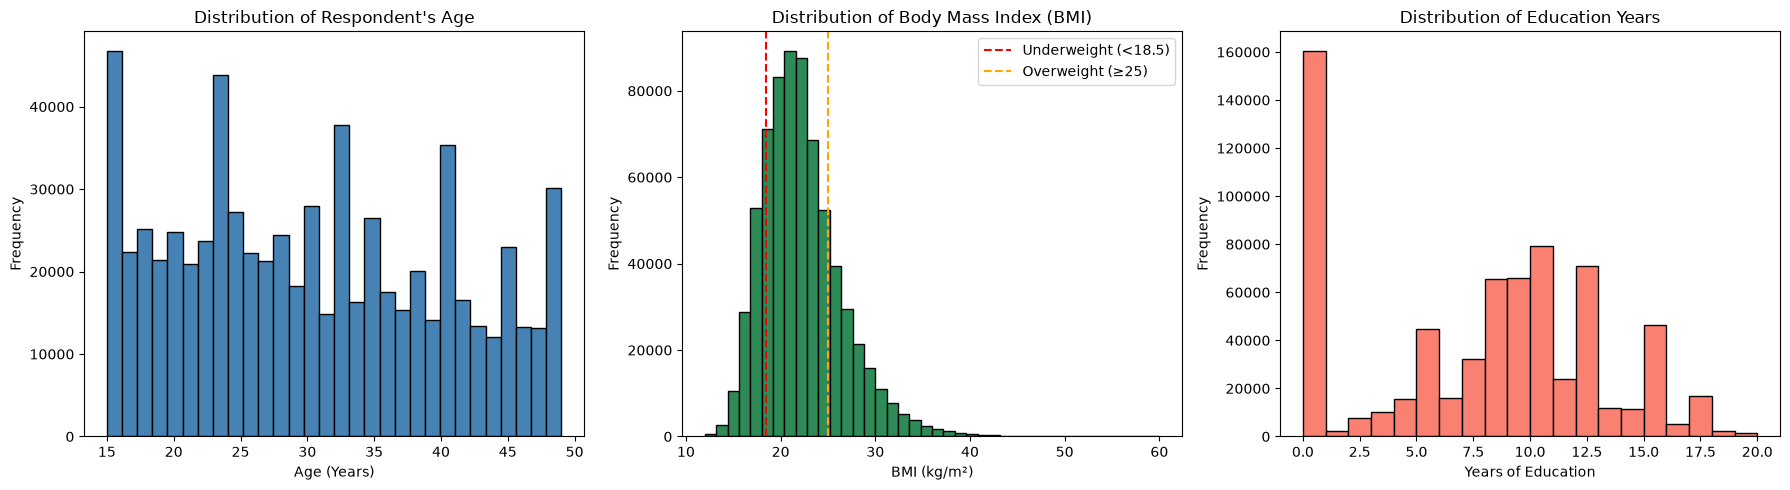

In [11]:
# 4.1 Univariate Analysis — Histograms
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Age
axes[0].hist(df_clean['v012'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of Respondent's Age")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Frequency")

# Body Mass Index (BMI)
# v445 is stored as BMI ×100 in DHS
axes[1].hist(df_clean['BMI'], bins=40, color='seagreen', edgecolor='black')
axes[1].axvline(18.5, color='red', linestyle='--', label='Underweight (<18.5)')
axes[1].axvline(25, color='orange', linestyle='--', label='Overweight (≥25)')
axes[1].set_title("Distribution of Body Mass Index (BMI)")
axes[1].set_xlabel("BMI (kg/m²)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Education Years
axes[2].hist(df_clean['v133'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title("Distribution of Education Years")
axes[2].set_xlabel("Years of Education")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4.2 Univariate Analysis — Categorical Counts

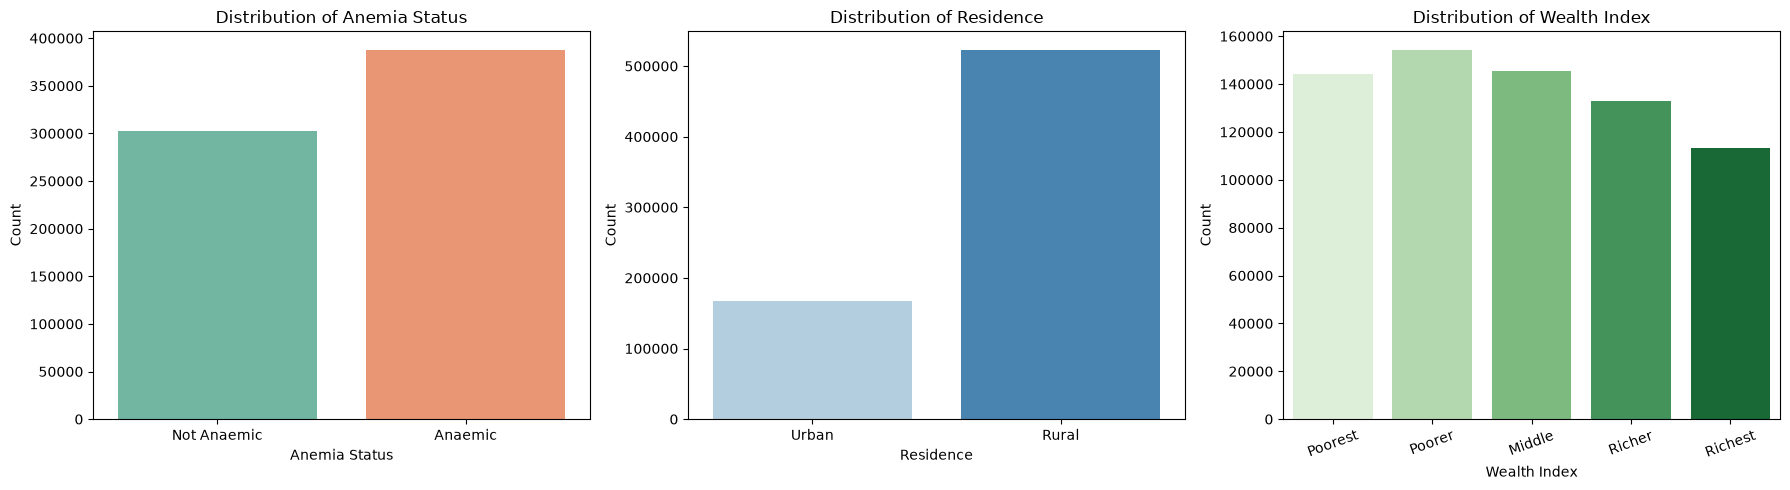

In [12]:
# 4.2 Univariate Analysis — Count Plots

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Anemia Status
sns.countplot(x='anemia_status', data=df_clean, palette='Set2', ax=axes[0])

axes[0].set_title("Distribution of Anemia Status")
axes[0].set_xlabel("Anemia Status")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Not Anaemic", "Anaemic"])

# Place of Residence
sns.countplot(x='v025', data=df_clean, palette='Blues', ax=axes[1])

axes[1].set_title("Distribution of Residence")
axes[1].set_xlabel("Residence")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Urban", "Rural"])

# Wealth Index
sns.countplot( x='v190', data=df_clean, palette='Greens', ax=axes[2])

axes[2].set_title("Distribution of Wealth Index")
axes[2].set_xlabel("Wealth Index")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels([
    "Poorest",
    "Poorer",
    "Middle",
    "Richer",
    "Richest"
], rotation=20)

plt.tight_layout()
plt.show()

### 4.3 Bivariate Analysis — Anaemia vs Wealth & Residence

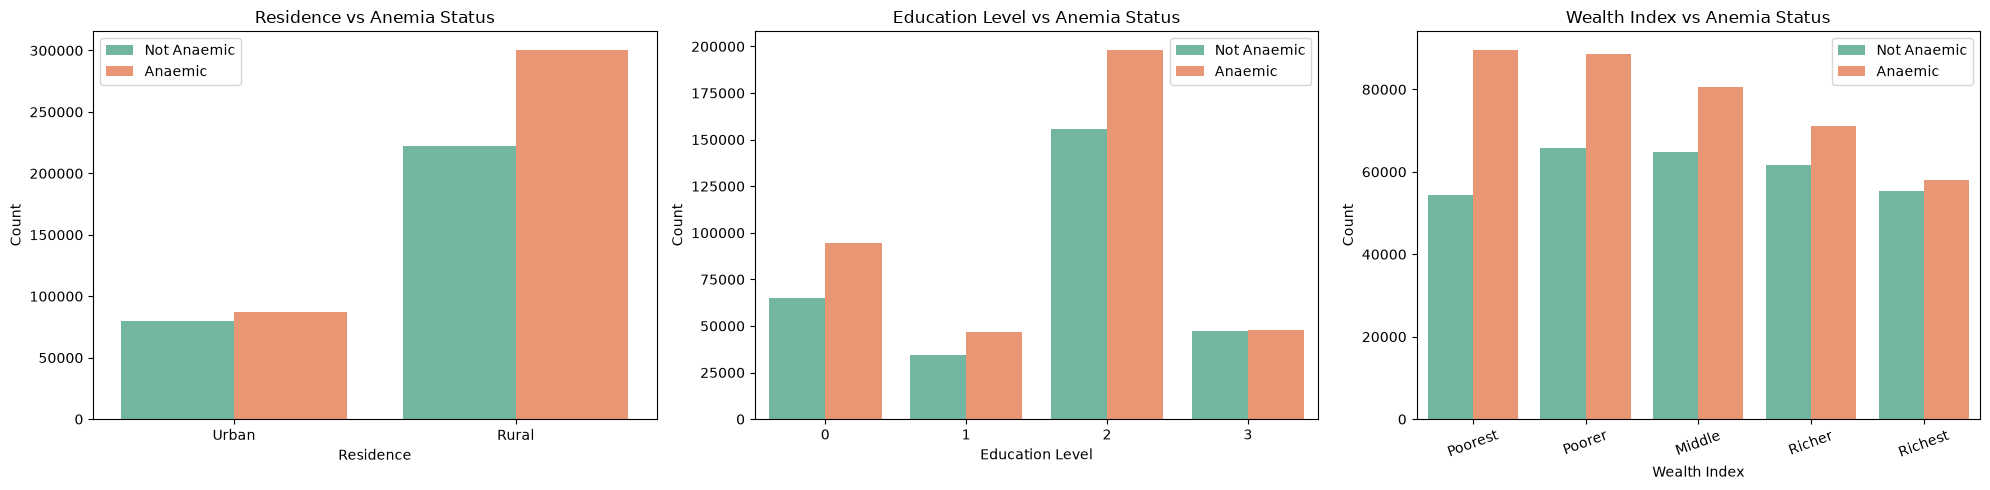

In [13]:
# 4.3 Bivariate Analysis — Categorical Variables vs Anemia
fig, axes = plt.subplots(1, 3, figsize=(20,5))

# Residence vs Anemia
sns.countplot(x='v025', hue='anemia_status', data=df_clean, palette='Set2', ax=axes[0])

axes[0].set_title("Residence vs Anemia Status")
axes[0].set_xlabel("Residence")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Urban", "Rural"])
axes[0].legend(["Not Anaemic", "Anaemic"])

# Education Level vs Anemia
sns.countplot(x='v106', hue='anemia_status', data=df_clean, palette='Set2', ax=axes[1])

axes[1].set_title("Education Level vs Anemia Status")
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Count")
axes[1].legend(["Not Anaemic", "Anaemic"])

# Wealth Index vs Anemia
sns.countplot(x='v190', hue='anemia_status', data=df_clean, palette='Set2', ax=axes[2])

axes[2].set_title("Wealth Index vs Anemia Status")
axes[2].set_xlabel("Wealth Index")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels([
    "Poorest",
    "Poorer",
    "Middle",
    "Richer",
    "Richest"
], rotation=20)

axes[2].legend(["Not Anaemic", "Anaemic"])

plt.tight_layout()
plt.show()

### 4.4 Boxplots — Hb & BMI vs Anaemia Level

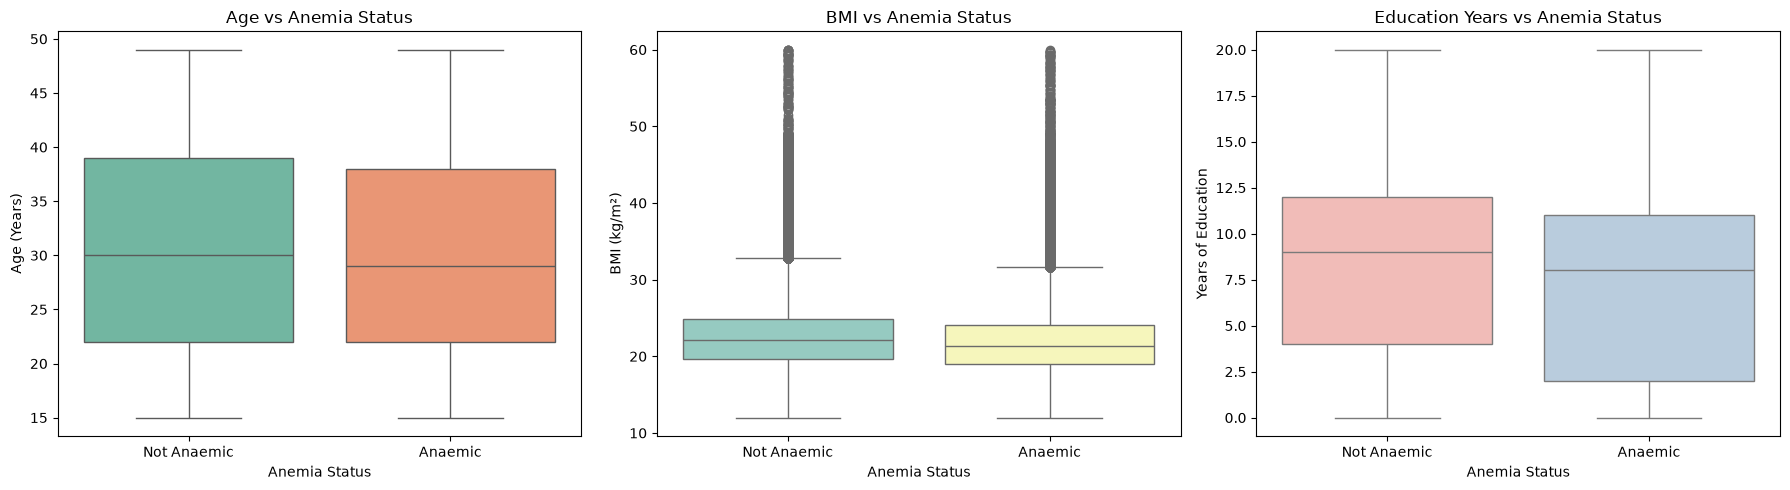

In [14]:
# 4.4 Bivariate Analysis — Continuous Variables vs Anemia
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Age vs Anemia Status
sns.boxplot(x='anemia_status',y='v012',data=df_clean,palette='Set2',ax=axes[0])

axes[0].set_title("Age vs Anemia Status")
axes[0].set_xlabel("Anemia Status")
axes[0].set_ylabel("Age (Years)")
axes[0].set_xticklabels(["Not Anaemic", "Anaemic"])

# BMI vs Anemia Status
sns.boxplot(x='anemia_status',y='BMI',data=df_clean,palette='Set3',ax=axes[1])

axes[1].set_title("BMI vs Anemia Status")
axes[1].set_xlabel("Anemia Status")
axes[1].set_ylabel("BMI (kg/m²)")
axes[1].set_xticklabels(["Not Anaemic", "Anaemic"])

# Education Years vs Anemia Status
sns.boxplot(x='anemia_status',y='v133',data=df_clean,palette='Pastel1',ax=axes[2])

axes[2].set_title("Education Years vs Anemia Status")
axes[2].set_xlabel("Anemia Status")
axes[2].set_ylabel("Years of Education")
axes[2].set_xticklabels(["Not Anaemic", "Anaemic"])

plt.tight_layout()
plt.show()

### 4.5 Correlation Heatmap

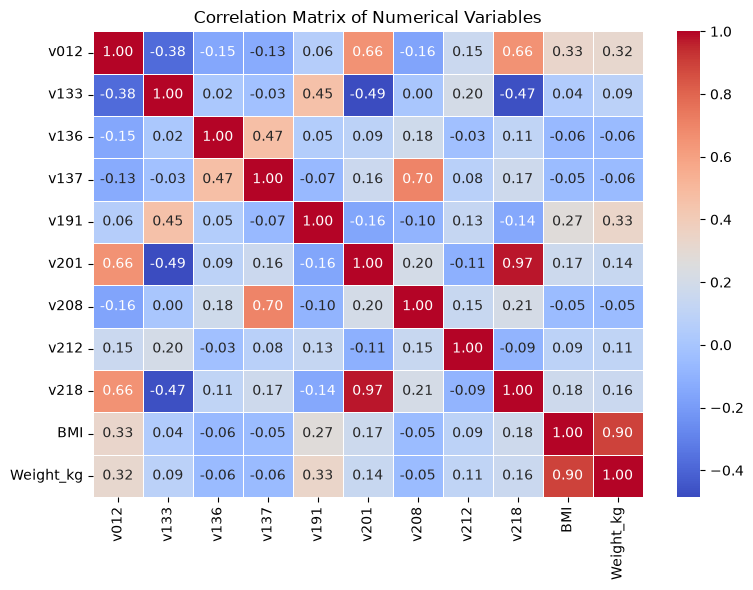

In [15]:
# 4.5 Correlation Analysis

correlation_variables = [

    'v012',      # Age
    'v133',      # Education Years
    'v136',      # Household Members
    'v137',      # Children Under Five
    'v191',      # Wealth Score
    'v201',      # Children Ever Born
    'v208',      # Births in Last 5 Years
    'v212',      # Age at First Birth
    'v218',      # Living Children
    'BMI',
    'Weight_kg'

]

corr_matrix = df_clean[correlation_variables].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 5. Statistical Hypothesis Testing

We perform **three** classical tests at significance level **α = 0.05**.

### 5.1 Test 1 — Chi-square Test

In [16]:
# 5.1 Chi-Square Test of Association

from scipy.stats import chi2_contingency

categorical_variables = [
    'v025',   # Residence
    'v106',   # Education Level
    'v190'    # Wealth Index
]

results = []

for var in categorical_variables:

    contingency_table = pd.crosstab(df_clean[var],
                                    df_clean['anemia_status'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        "Variable": var,
        "Chi-Square": round(chi2,2),
        "Degrees of Freedom": dof,
        "P-Value": round(p,5)
    })

chi_square_results = pd.DataFrame(results)
chi_square_results

,Variable,Chi-Square,Degrees of Freedom,P-Value
0,v025,1428.15,1,0.0
1,v106,1965.67,3,0.0
2,v190,3808.25,4,0.0


### 5.2 Test 2 — Welch Independent T-test

In [17]:
# 5.2 Independent Samples t-Test

from scipy.stats import ttest_ind

continuous_variables = [
    'v012',      # Age
    'BMI',
    'v133',      # Education Years
    'v191',      # Wealth Score
    'v212'       # Age at First Birth
]

results = []

for var in continuous_variables:
    group1 = df_clean[df_clean['anemia_status']==1][var].dropna()
    group0 = df_clean[df_clean['anemia_status']==0][var].dropna()

    t_stat, p_value = ttest_ind(group1, group0)
    results.append({
        "Variable": var,
        "T-Statistic": round(t_stat,2),
        "P-Value": round(p_value,5)
    })

ttest_results = pd.DataFrame(results)
ttest_results

,Variable,T-Statistic,P-Value
0,v012,-17.30,0.0
1,BMI,-66.87,0.0
2,v133,-44.36,0.0
3,v191,-64.28,0.0
4,v212,-19.03,0.0


In [18]:
# 5.3 Interpretation of Statistical Tests
print("STATISTICAL HYPOTHESIS TESTING SUMMARY")

print("\nChi-Square Test")
display(chi_square_results)

print("\nIndependent Samples t-Test")
display(ttest_results)

STATISTICAL HYPOTHESIS TESTING SUMMARY

Chi-Square Test


,Variable,Chi-Square,Degrees of Freedom,P-Value
0,v025,1428.15,1,0.0
1,v106,1965.67,3,0.0
2,v190,3808.25,4,0.0



Independent Samples t-Test


,Variable,T-Statistic,P-Value
0,v012,-17.30,0.0
1,BMI,-66.87,0.0
2,v133,-44.36,0.0
3,v191,-64.28,0.0
4,v212,-19.03,0.0


## 6. Predictive Modelling

### 6.1 Build the Modelling Dataset

The cleaned dataset contains over 690,000 rows. Fitting heavy ensembles on the full set is wasteful; we draw a stratified **random sample of 30,000 rows** (with `random_state=42`) — large enough for stable estimates while keeping run-time reasonable. All five required techniques are applied to this sample.

In [19]:
# 6.1 Feature Selection

features = [
    'v012',      # Age
    'v013',      # Age Group
    'v024',      # State
    'v025',      # Residence

    'v106',      # Education Level
    'v113',      # Drinking Water
    'v116',      # Toilet Facility
    'v119',      # Electricity
    'v121',      # Television
    'v130',      # Religion

    'v133',      # Education Years
    'v136',      # Household Members
    'v137',      # Children Under Five

    'v155',      # Literacy
    'v161',      # Cooking Fuel

    'v190',      # Wealth Index
    'v191',      # Wealth Score

    'v201',      # Children Ever Born
    'v208',      # Births Last 5 Years
    'v212',      # Age at First Birth
    'v213',      # Currently Pregnant
    'v218',      # Living Children
    'v228',      # Pregnancy Terminated

    'v312',      # Current Contraceptive Method
    'v313',      # Contraceptive Method Type

    'v501',      # Marital Status

    'BMI'
]

X = df_clean[features]
y = df_clean['anemia_status']

print("FEATURE MATRIX")

print("Number of Features :", X.shape[1])
print("Number of Records  :", X.shape[0])

FEATURE MATRIX
Number of Features : 27
Number of Records  : 690153


### 6.2 Train-Test Split

In [20]:
# 6.2 Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("TRAIN-TEST SPLIT")

print("Training Records :", X_train.shape[0])
print("Testing Records  :", X_test.shape[0])

print("\nTraining Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

TRAIN-TEST SPLIT
Training Records : 552122
Testing Records  : 138031

Training Target Distribution
anemia_status
1    310239
0    241883
Name: count, dtype: int64

Testing Target Distribution
anemia_status
1    77560
0    60471
Name: count, dtype: int64


### 6.3 Feature Scaling

We will scale after the train-test split.

In [21]:
# 6.3 Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("FEATURE SCALING COMPLETED")
print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Training Shape : (552122, 27)
Testing Shape  : (138031, 27)


### 6.4 Handle Class Imbalance using SMOTE (Synthetic Minority Over-sampling)

SMOTE should be applied only to the training data.

In [22]:
# 6.4 Handle Class Imbalance using SMOTE

from imblearn.over_sampling import SMOTE

print("Before SMOTE")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
anemia_status
1    310239
0    241883
Name: count, dtype: int64

After SMOTE
anemia_status
0    310239
1    310239
Name: count, dtype: int64


### 6.5 Logistic Regression

Logistic regression is the workhorse of epidemiology because the exponentiated coefficients are interpretable as **odds ratios** — directly answering "how does each factor change the odds of anaemia?".

In [23]:
# 6.5 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_smote, y_train_smote)
y_pred_lr = logistic_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
Accuracy  : 0.5492
Precision : 0.6075
Recall    : 0.5586
F1-Score  : 0.5820

Classification Report
              precision    recall  f1-score   support

           0       0.49      0.54      0.51     60471
           1       0.61      0.56      0.58     77560

    accuracy                           0.55    138031
   macro avg       0.55      0.55      0.55    138031
weighted avg       0.55      0.55      0.55    138031



### 6.6 Decision Tree Classifier

In [24]:
# 6.6 Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)

decision_tree.fit(X_train_smote, y_train_smote)
y_pred_dt = decision_tree.predict(X_test_scaled)

print("DECISION TREE")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_dt):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

DECISION TREE
Accuracy  : 0.5878
Precision : 0.6239
Recall    : 0.6708
F1-Score  : 0.6465

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.48      0.51     60471
           1       0.62      0.67      0.65     77560

    accuracy                           0.59    138031
   macro avg       0.58      0.58      0.58    138031
weighted avg       0.58      0.59      0.58    138031



### 6.7 Random Forest
Instead of using the default Random Forest, these settings help control overfitting while still capturing nonlinear relationships:

n_estimators=200 → More stable predictions.
max_depth=15 → Prevents overly deep trees.
min_samples_split=20 → Reduces overfitting.
min_samples_leaf=10 → Produces more robust terminal nodes.

In [25]:
# 6.7 Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_smote, y_train_smote)
y_pred_rf = random_forest.predict(X_test_scaled)

print("RANDOM FOREST")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy  : 0.5945
Precision : 0.6257
Recall    : 0.6927
F1-Score  : 0.6575

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.47      0.50     60471
           1       0.63      0.69      0.66     77560

    accuracy                           0.59    138031
   macro avg       0.58      0.58      0.58    138031
weighted avg       0.59      0.59      0.59    138031



### 6.8 XGBoost (Extreme Gradient Boosting)

A regularised gradient-boosted-tree implementation that consistently wins on tabular benchmarks.
Instead of using the default model:

n_estimators=200 → More boosting rounds.
max_depth=6 → Controls complexity.
learning_rate=0.05 → More stable learning.
subsample=0.8 → Reduces overfitting.
colsample_bytree=0.8 → Uses random feature subsets.

In [26]:
# 6.8 XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

xgb_model = XGBClassifier(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBOOST CLASSIFIER")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_xgb):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

XGBOOST CLASSIFIER
Accuracy  : 0.6034
Precision : 0.6191
Recall    : 0.7644
F1-Score  : 0.6842

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.40      0.47     60471
           1       0.62      0.76      0.68     77560

    accuracy                           0.60    138031
   macro avg       0.59      0.58      0.58    138031
weighted avg       0.60      0.60      0.59    138031



### 6.9 Model Comparison

In [27]:
# 6.9 Model Performance Comparison

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision":[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1-Score":[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]

})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.5492,0.6075,0.5586,0.5820
1,Decision Tree,0.5878,0.6239,0.6708,0.6465
2,Random Forest,0.5945,0.6257,0.6927,0.6575
3,XGBoost,0.6034,0.6191,0.7644,0.6842


### 6.10 Model Comparison Bar Chart

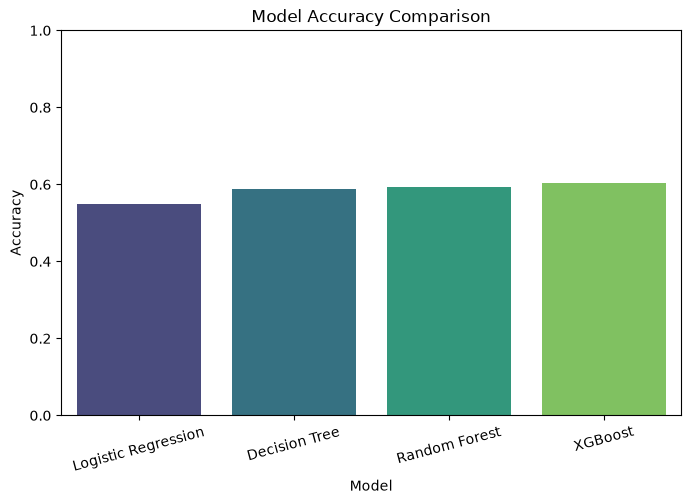

In [28]:
# 6.10 Accuracy Comparison

plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x="Model", y="Accuracy", palette="viridis")

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.show()

### 6.11 Confusion Matrices

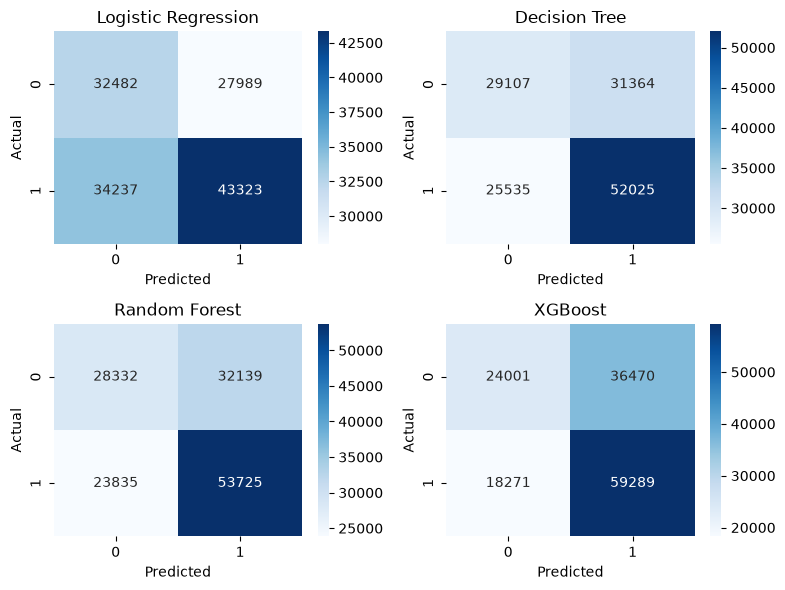

In [29]:
# 6.11 Confusion Matrices

from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(2,2, figsize=(8,6))
models = {

    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb

}

for ax, (name, pred) in zip(axes.flat, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 6.12 Feature Importance

TOP 15 MOST IMPORTANT FEATURES


,Feature,Importance
9,v130,0.123723
11,v136,0.118349
10,v133,0.088650
6,v116,0.085991
2,v024,0.075537
14,v161,0.075236
15,v190,0.061051
5,v113,0.060906
1,v013,0.044096
26,BMI,0.032284


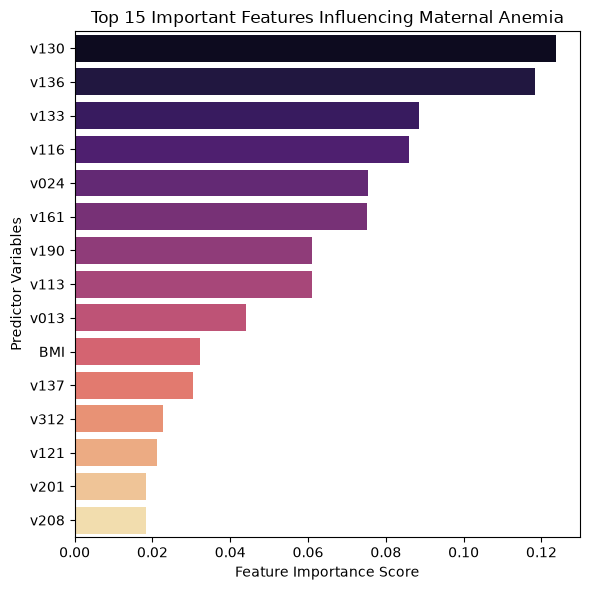

In [30]:
# 6.12 Feature Importance (XGBoost)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 15 MOST IMPORTANT FEATURES")
display(importance.head(15))

# Feature Importance Plot
plt.figure(figsize=(6,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature", palette="magma")

plt.title("Top 15 Important Features Influencing Maternal Anemia")
plt.xlabel("Feature Importance Score")
plt.ylabel("Predictor Variables")

plt.tight_layout()
plt.show()

# 7. Conclusion

This study analyzed the determinants of maternal anemia among women using the National Family Health Survey-5 (NFHS-5) dataset. The dataset was preprocessed by handling missing values, cleaning variables, creating derived features, and performing exploratory data analysis to understand the characteristics of the data.

Statistical hypothesis testing using Chi-square tests and Independent Samples t-tests revealed significant associations between maternal anemia and several demographic and socioeconomic factors, including place of residence, education level, wealth index, age, BMI, and age at first birth (p < 0.05).

To predict maternal anemia, four machine learning algorithms were developed and evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost. The data were standardized, class imbalance was addressed using SMOTE, and the models were evaluated using Accuracy, Precision, Recall, and F1-score.

Among the evaluated models, XGBoost achieved the best overall performance with an accuracy of approximately 60.34% and an F1-score of 68.42%, followed by Random Forest, Decision Tree, and Logistic Regression. Feature importance analysis indicated that religion, household size, literacy, toilet facility, region, cooking fuel, wealth index, drinking water source, age group, and BMI were among the most influential predictors of maternal anemia.

Overall, the findings demonstrate that maternal anemia is influenced by a combination of demographic, socioeconomic, reproductive, and nutritional factors. Machine learning techniques can effectively support the identification of women at higher risk of anemia, providing useful insights for public health planning and targeted intervention programs.

# 8. Future Scope

The present study focused on binary classification of maternal anemia using selected demographic, socioeconomic, and reproductive variables from the NFHS-5 dataset. Future research may improve predictive performance by incorporating additional nutritional, clinical, and behavioral variables. Advanced machine learning and deep learning models may also be explored and compared with the models used in this study.

Further studies may extend this work by developing region-specific prediction models, applying explainable artificial intelligence (XAI) techniques such as SHAP or LIME for model interpretation, and integrating real-time healthcare data to support early identification of women at risk of anemia. Such approaches can assist policymakers and healthcare professionals in designing targeted maternal health interventions.

# Thank You